<a href="https://www.kaggle.com/code/lalit7881/global-e-commerce-sales-2021-24-eda?scriptVersionId=308821340" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abdelfattahibrahim/global-e-commerce-sales-dataset-20212024/ecommerce_sales_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abdelfattahibrahim/global-e-commerce-sales-dataset-20212024/ecommerce_sales_dataset.csv")

In [3]:
df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [4]:
df.tail()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
9995,ORD-009996,2023-07-15,2023,7,Q3,Summer,CUST-01740,Female,Regular,Europe,...,0.10,347.98,226.84,121.14,34.81,30.56,Express,12,Cash on Delivery,Returned
9996,ORD-009997,2022-01-01,2022,1,Q1,Winter,CUST-01137,Female,Regular,Asia,...,0.40,20.18,21.22,-1.04,-5.15,7.48,Standard,16,Google Pay,Returned
9997,ORD-009998,2024-04-23,2024,4,Q2,Spring,CUST-01664,Female,Regular,Asia,...,0.15,45.56,25.79,19.77,43.39,23.80,Express,12,Google Pay,Delivered
9998,ORD-009999,2021-09-22,2021,9,Q3,Fall,CUST-04665,Male,Regular,North America,...,0.25,1550.95,1131.45,419.50,27.05,15.81,Standard,7,Apple Pay,Delivered
9999,ORD-010000,2023-03-25,2023,3,Q1,Spring,CUST-05360,Female,Regular,Middle East,...,0.10,111.32,79.40,31.92,28.67,20.67,Express,9,Google Pay,Delivered


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Order_Date        10000 non-null  object 
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  object 
 5   Season            10000 non-null  object 
 6   Customer_ID       10000 non-null  object 
 7   Customer_Gender   10000 non-null  object 
 8   Customer_Segment  10000 non-null  object 
 9   Region            10000 non-null  object 
 10  Country           10000 non-null  object 
 11  Category          10000 non-null  object 
 12  Sub_Category      10000 non-null  object 
 13  Product_Name      10000 non-null  object 
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64

In [6]:
df.describe()

,Year,Month,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2022.756300,6.604300,236.307452,2.731300,0.17675,528.438770,384.674939,143.763831,23.648594,32.299889,11.436100
std,0.878628,3.406799,380.901351,2.038508,0.16167,1154.811538,828.069100,420.487992,21.496639,28.424003,5.347633
min,2021.000000,1.000000,10.010000,1.000000,0.00000,5.330000,4.850000,-1572.900000,-50.000000,2.000000,3.000000
25%,2022.000000,4.000000,42.767500,1.000000,0.00000,67.227500,50.017500,9.007500,13.497500,8.260000,7.000000
50%,2023.000000,7.000000,92.495000,2.000000,0.15000,164.600000,121.395000,34.745000,28.330000,20.300000,10.000000
75%,2023.000000,10.000000,221.822500,4.000000,0.30000,469.952500,339.020000,118.475000,39.082500,50.362500,15.000000
max,2024.000000,12.000000,2497.760000,10.000000,0.50000,19966.500000,15729.670000,9144.150000,54.990000,99.990000,25.000000


In [7]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Order_ID             object
Order_Date           object
Year                  int64
Month                 int64
Quarter              object
Season               object
Customer_ID          object
Customer_Gender      object
Customer_Segment     object
Region               object
Country              object
Category             object
Sub_Category         object
Product_Name         object
Unit_Price          float64
Quantity              int64
Discount            float64
Revenue             float64
Cost                float64
Profit              float64
Profit_Margin_%     float64
Shipping_Cost       float64
Shipping_Method      object
Shipping_Days         int64
Payment_Method       object
Order_Status         object
dtype: object

In [10]:
df.shape

(10000, 26)

In [11]:
df.columns

Index(['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season',
       'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%',
       'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method',
       'Order_Status'],
      dtype='object')

In [12]:
df.nunique()

Order_ID            10000
Order_Date           1355
Year                    4
Month                  12
Quarter                 4
Season                  4
Customer_ID          5348
Customer_Gender         2
Customer_Segment        4
Region                  4
Country                18
Category                5
Sub_Category           14
Product_Name           70
Unit_Price           8391
Quantity               10
Discount                9
Revenue              9066
Cost                 8824
Profit               7973
Profit_Margin_%      5263
Shipping_Cost        5276
Shipping_Method         4
Shipping_Days          23
Payment_Method          7
Order_Status            4
dtype: int64

In [13]:
# Set style
plt.style.use('default')
sns.set_theme(style="whitegrid")

## EDA

In [14]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Quick check
print(df.head())
print(df.info())

     Order_ID Order_Date  Year  Month Quarter  Season Customer_ID  \
0  ORD-000001 2023-01-18  2023      1      Q1  Winter  CUST-02791   
1  ORD-000002 2023-11-13  2023     11      Q4    Fall  CUST-02763   
2  ORD-000003 2022-04-28  2022      4      Q2  Spring  CUST-05729   
3  ORD-000004 2021-10-22  2021     10      Q4    Fall  CUST-06490   
4  ORD-000005 2023-08-06  2023      8      Q3  Summer  CUST-07594   

  Customer_Gender Customer_Segment         Region  ... Discount  Revenue  \
0            Male              New  North America  ...     0.00  3642.80   
1          Female          Regular  North America  ...     0.25    33.88   
2            Male          Regular  North America  ...     0.00   241.30   
3          Female          Regular           Asia  ...     0.00   654.50   
4          Female          Premium         Europe  ...     0.20   178.82   

      Cost   Profit  Profit_Margin_%  Shipping_Cost  Shipping_Method  \
0  2444.11  1198.69            32.91           2.25     

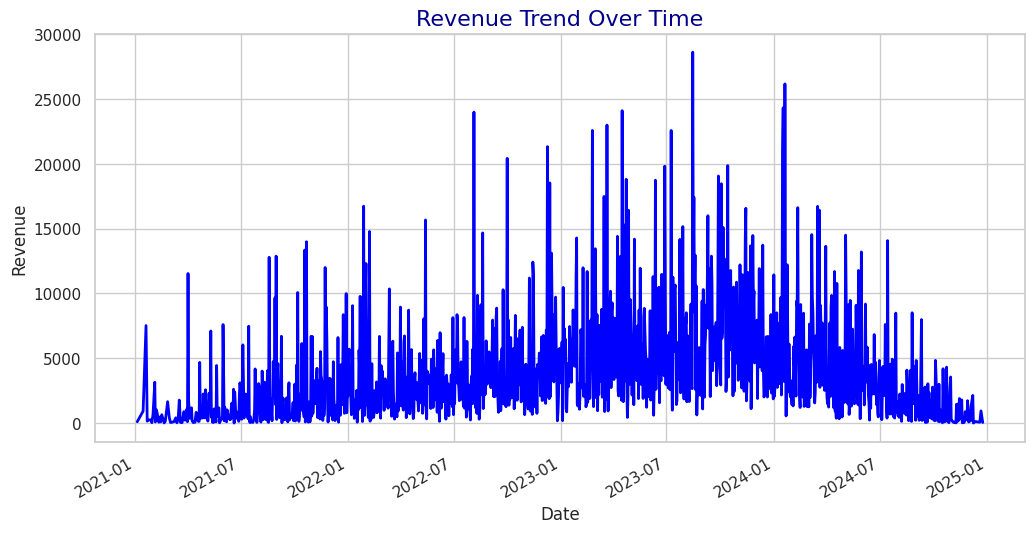

In [15]:
plt.figure(figsize=(12,6))
df.groupby('Order_Date')['Revenue'].sum().plot(color='blue', linewidth=2)

plt.title("Revenue Trend Over Time", fontsize=16, color='darkblue')
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

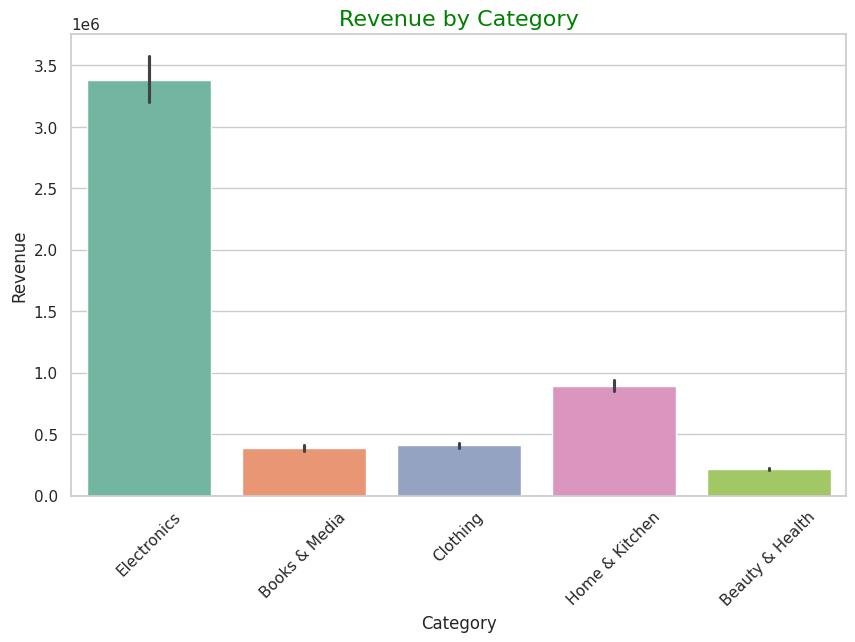

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Category', 
    y='Revenue', 
    data=df, 
    estimator=sum, 
    palette='Set2'
)

plt.title("Revenue by Category", fontsize=16, color='green')
plt.xticks(rotation=45)
plt.show()

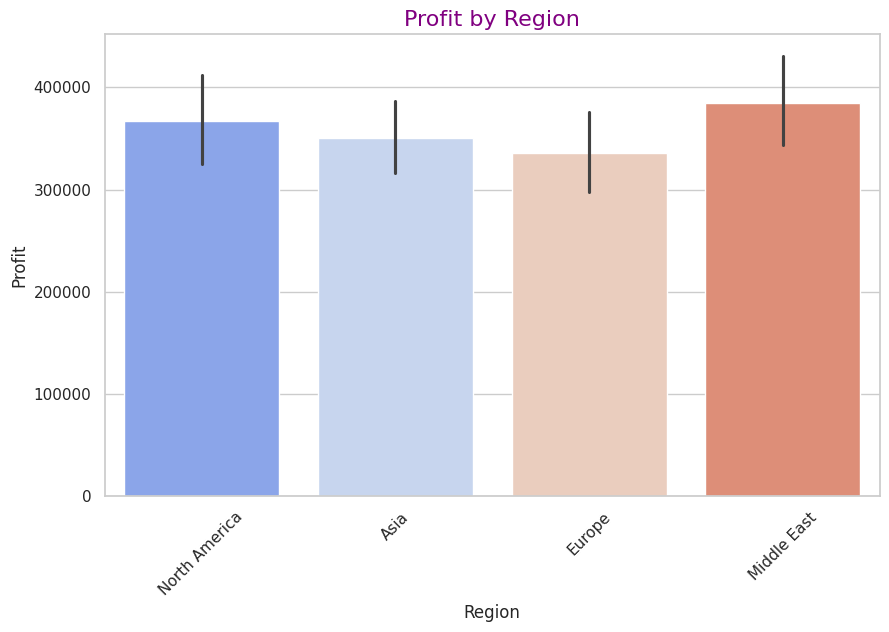

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Region', 
    y='Profit', 
    data=df, 
    estimator=sum, 
    palette='coolwarm'
)

plt.title("Profit by Region", fontsize=16, color='purple')
plt.xticks(rotation=45)
plt.show()

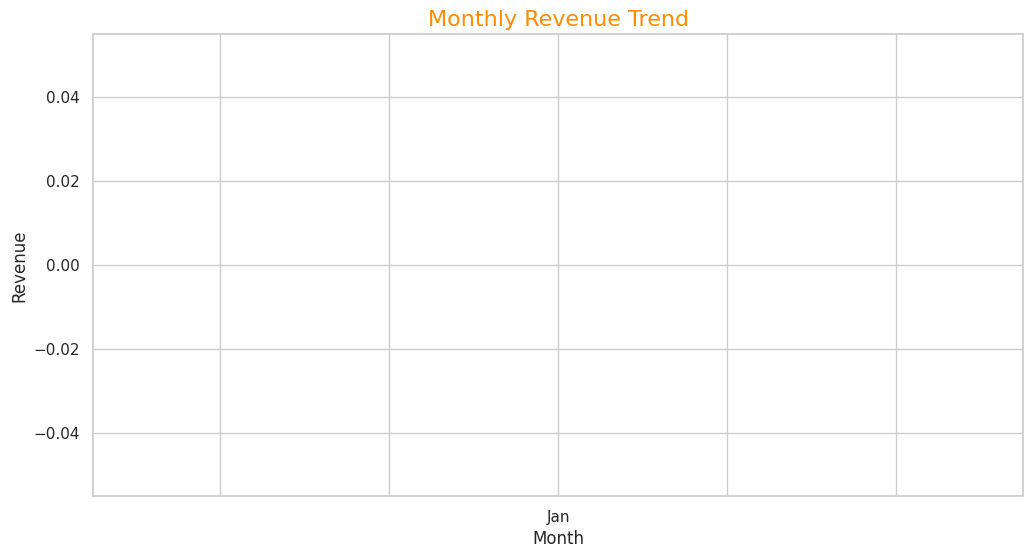

In [18]:
monthly_sales = df.groupby('Month')['Revenue'].sum().reindex([
    'Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'
])

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='orange')

plt.title("Monthly Revenue Trend", fontsize=16, color='darkorange')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

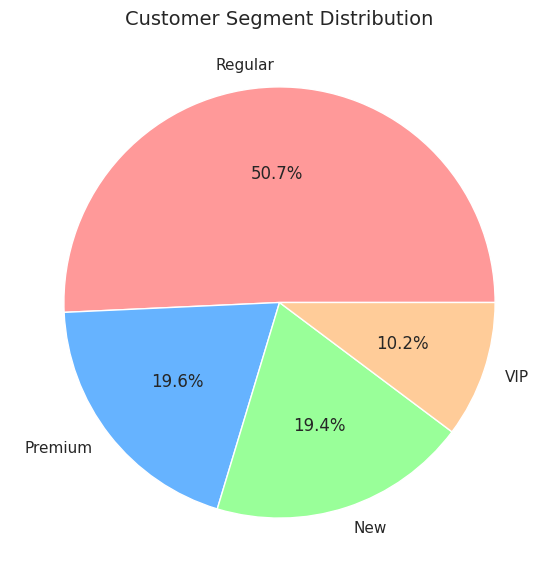

In [19]:
plt.figure(figsize=(7,7))
df['Customer_Segment'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)

plt.title("Customer Segment Distribution", fontsize=14)
plt.ylabel('')
plt.show()

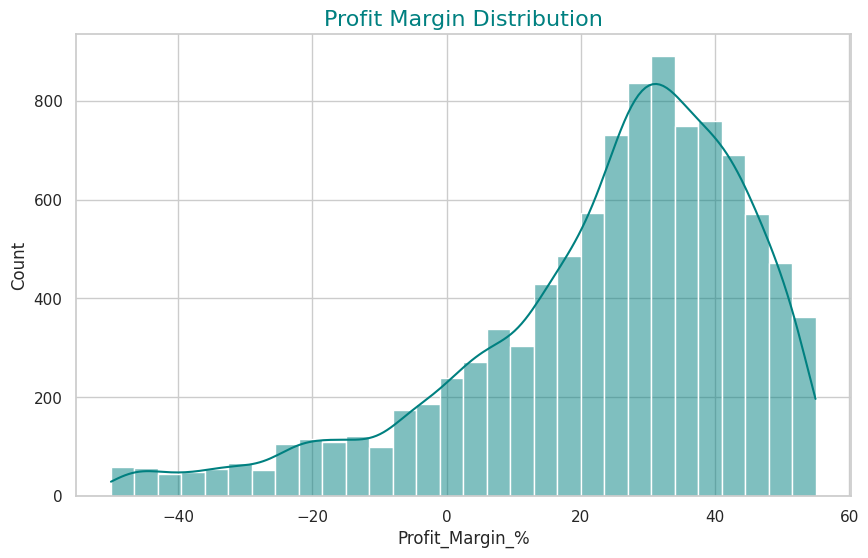

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['Profit_Margin_%'], bins=30, kde=True, color='teal')

plt.title("Profit Margin Distribution", fontsize=16, color='teal')
plt.show()

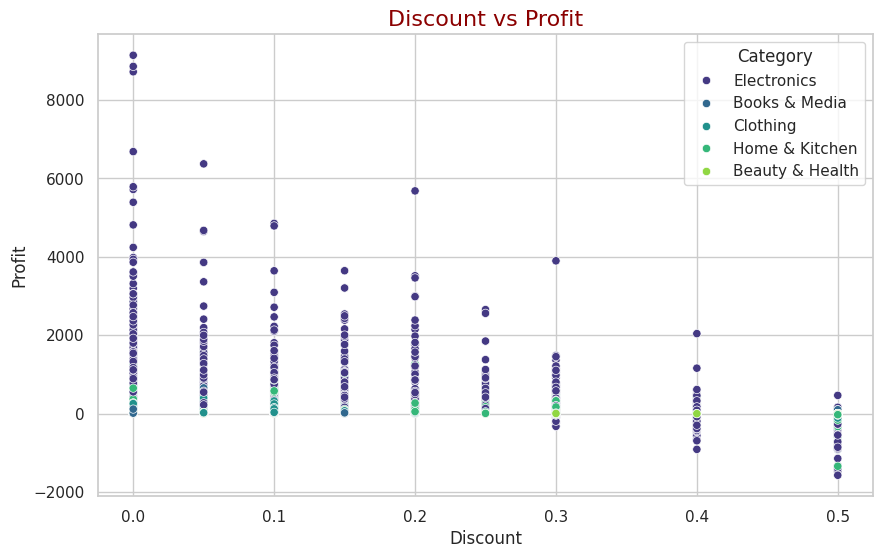

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Discount', 
    y='Profit', 
    hue='Category', 
    data=df, 
    palette='viridis'
)

plt.title("Discount vs Profit", fontsize=16, color='darkred')
plt.show()

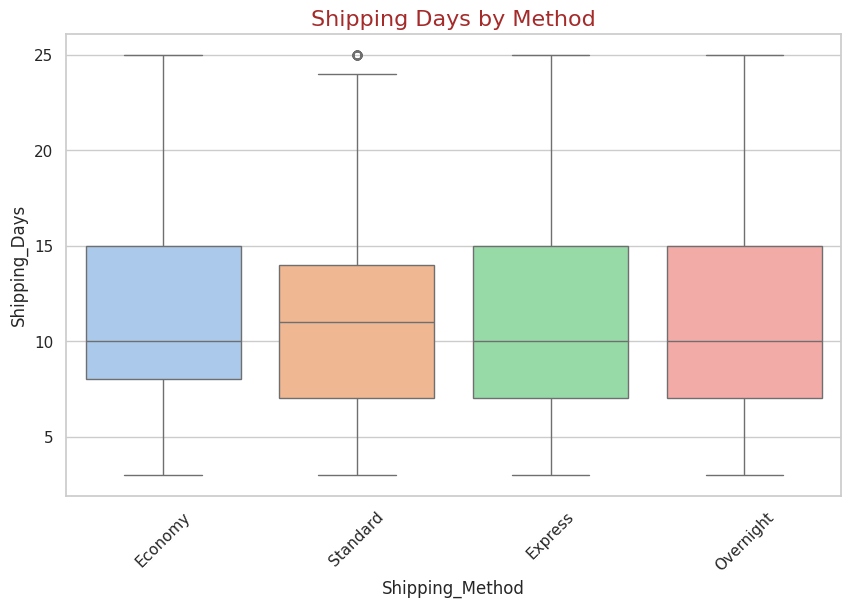

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Shipping_Method', 
    y='Shipping_Days', 
    data=df, 
    palette='pastel'
)

plt.title("Shipping Days by Method", fontsize=16, color='brown')
plt.xticks(rotation=45)
plt.show()

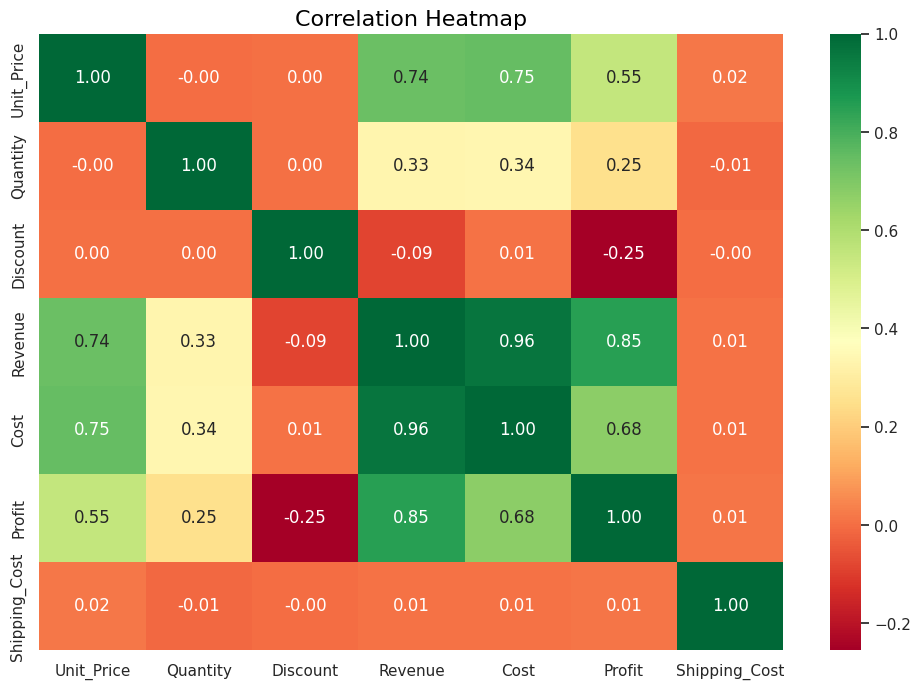

In [23]:
plt.figure(figsize=(12,8))
corr = df[['Unit_Price','Quantity','Discount','Revenue','Cost','Profit','Shipping_Cost']].corr()

sns.heatmap(
    corr, 
    annot=True, 
    cmap='RdYlGn', 
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16, color='black')
plt.show()

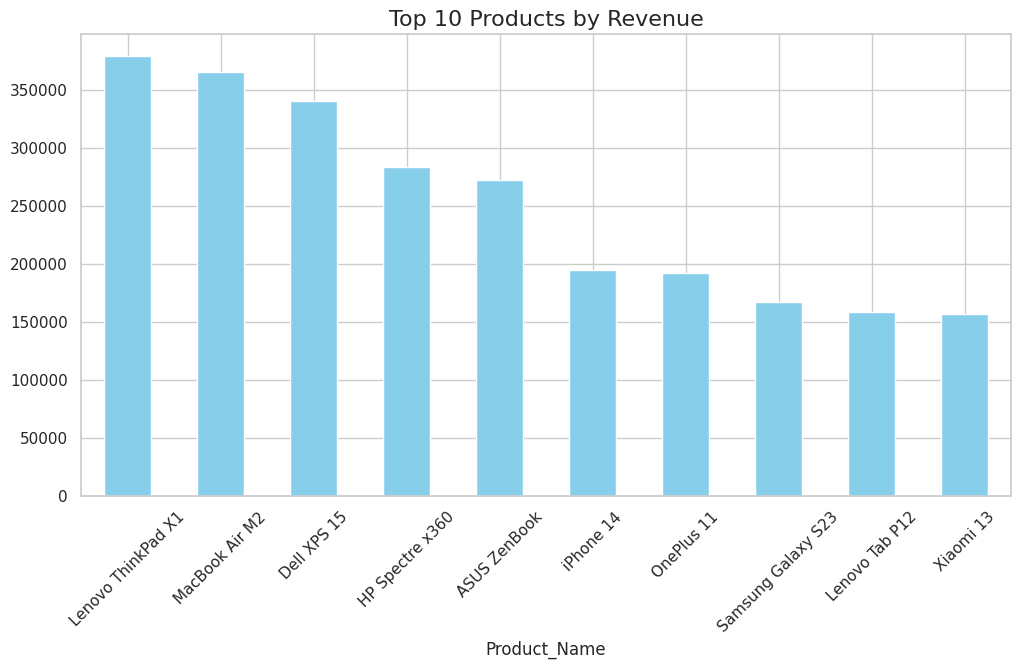

In [24]:
top_products = df.groupby('Product_Name')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='skyblue')

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xticks(rotation=45)
plt.show()

## Feature engineering

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Convert date
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Check data
print(df.head())

     Order_ID Order_Date  Year  Month Quarter  Season Customer_ID  \
0  ORD-000001 2023-01-18  2023      1      Q1  Winter  CUST-02791   
1  ORD-000002 2023-11-13  2023     11      Q4    Fall  CUST-02763   
2  ORD-000003 2022-04-28  2022      4      Q2  Spring  CUST-05729   
3  ORD-000004 2021-10-22  2021     10      Q4    Fall  CUST-06490   
4  ORD-000005 2023-08-06  2023      8      Q3  Summer  CUST-07594   

  Customer_Gender Customer_Segment         Region  ... Discount  Revenue  \
0            Male              New  North America  ...     0.00  3642.80   
1          Female          Regular  North America  ...     0.25    33.88   
2            Male          Regular  North America  ...     0.00   241.30   
3          Female          Regular           Asia  ...     0.00   654.50   
4          Female          Premium         Europe  ...     0.20   178.82   

      Cost   Profit  Profit_Margin_%  Shipping_Cost  Shipping_Method  \
0  2444.11  1198.69            32.91           2.25     

In [27]:
target = 'Order_Status'

In [28]:
drop_cols = [
    'Order_ID', 
    'Customer_ID',
    'Order_Date'
]

df = df.drop(columns=drop_cols)

In [29]:
X = df.drop(columns=[target])
y = df[target]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
le_dict = {}

for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  # Only transform
    
    le_dict[col] = le

# Encode target
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [35]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

In [36]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.6275
Random Forest Accuracy: 0.627
Naive Bayes Accuracy: 0.607

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.63      1.00      0.77      1255
           2       0.00      0.00      0.00       192
           3       0.25      0.00      0.01       371

    accuracy                           0.63      2000
   macro avg       0.22      0.25      0.19      2000
weighted avg       0.44      0.63      0.48      2000



In [37]:
from sklearn.preprocessing import label_binarize

n_classes = len(np.unique(y_train))

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

In [38]:
y_prob_lr = lr.predict_proba(X_test)
y_prob_rf = rf.predict_proba(X_test)
y_prob_nb = nb.predict_proba(X_test)

In [39]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

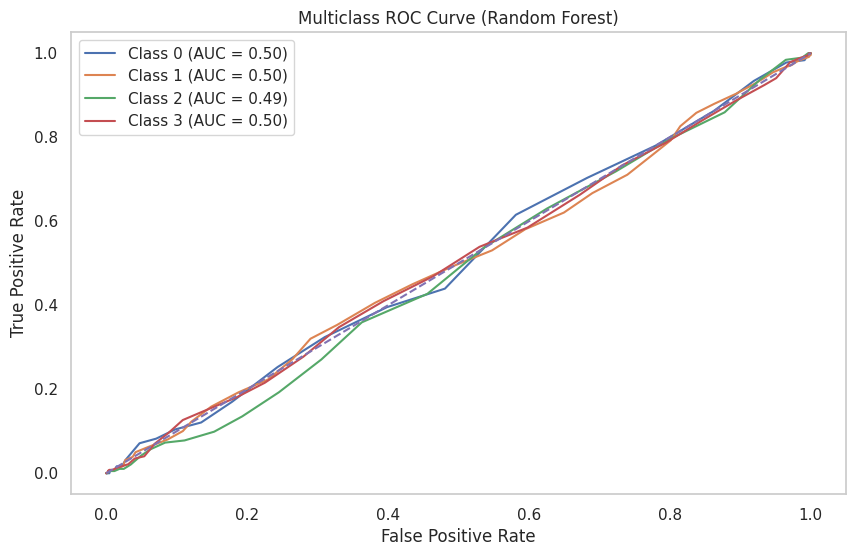

In [40]:
plt.figure(figsize=(10,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'--')

plt.title("Multiclass ROC Curve (Random Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

## Thank you...pls upvote!!!!!!